In [1]:
# Projet : Classification du Cancer du Sein

# Objectif

# L'objectif de ce projet est de développer des modèles de Machine Learning capables de prédire si une tumeur mammaire est :

#- Bénigne (B)
#- Maligne (M)

#à partir de 30 caractéristiques numériques extraites d’images de biopsies.

#Ce problème est un problème de **classification supervisée binaire**.

# Nous allons suivre les étapes classiques d’un projet de Machine Learning :
# 1. Exploration des données
# 2. Prétraitement
# 3. Construction des modèles
# 4. Évaluation
# 5. Interprétation des résultats


In [1]:
#1)a
import numpy as np
import pandas as pd
import matplotlib as plt
#1)b
df=pd.read_csv("Breast Cancer Wisconsin.csv")
pd.set_option('display.max_columns', None)
print(df.head())
print(df.info())
print(df['diagnosis'].value_counts())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  fractal_dimension_mean  radius_se  texture_s

In [2]:
#2)a
df=df.drop(['id','Unnamed: 32'],axis=1)
print(df.columns)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [3]:
#2)b
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
X=df.drop('diagnosis',axis=1)
y=df['diagnosis']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)
#2)c 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [4]:
#3)
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression()
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=23)
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()



In [5]:
#4)
log_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
y_predlog=log_model.predict(X_test)
y_predknn=knn_model.predict(X_test)
y_predtree=tree_model.predict(X_test)

In [7]:
#5)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#regression logistic
print("logistic regression model")
print("Accuracy:", accuracy_score(y_test, y_predlog))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predlog))
print("Report:\n", classification_report(y_test, y_predlog))
#knn
print(" knn model")
print("Accuracy:", accuracy_score(y_test, y_predknn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predknn))
print("Report:\n", classification_report(y_test, y_predknn))
print("decision tree model")
print("Accuracy:", accuracy_score(y_test, y_predtree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predtree))
print("Report:\n", classification_report(y_test, y_predtree))


logistic regression model
Accuracy: 0.9736842105263158
Confusion Matrix:
 [[70  1]
 [ 2 41]]
Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

 knn model
Accuracy: 0.9473684210526315
Confusion Matrix:
 [[69  2]
 [ 4 39]]
Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

decision tree model
Accuracy: 0.9473684210526315
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Report:
               precision    recall  f1-score   support

      

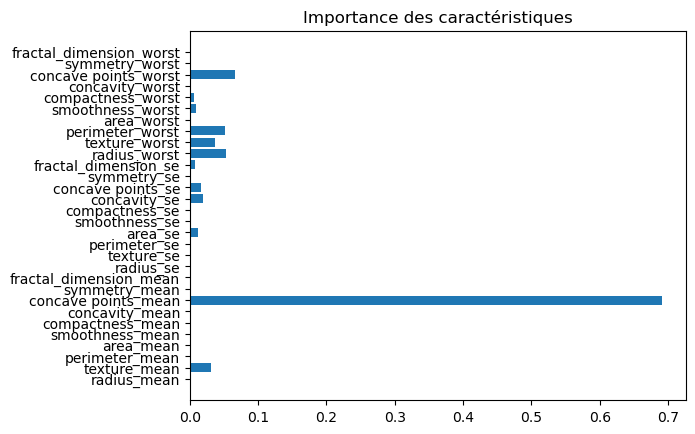

In [8]:
import matplotlib.pyplot as plt

importances = tree_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Importance des caractéristiques")
plt.show()

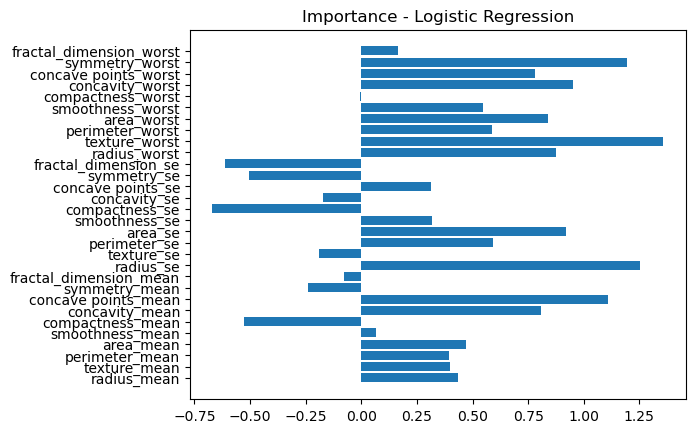

In [9]:
importances = log_model.coef_[0]
features = X.columns

plt.barh(features, importances)
plt.title("Importance - Logistic Regression")
plt.show()

In [11]:
import numpy as np

# importance from permutation
from sklearn.inspection import permutation_importance

result = permutation_importance(
    knn_model, X_test, y_test,
    n_repeats=10,
    random_state=42
)
importances = result.importances_mean
features = X.columns

# get index of max importance
index = np.argmax(importances)

print("Most important feature (KNN):", features[index])

Most important feature (KNN): perimeter_se


In [ ]:
import numpy as np

features = []

feature_names = [
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst"
]

for feature in feature_names:
    value = float(input(f"{feature}: "))
    features.append(value)

input_data = np.array([features])

# input_data = scaler.transform(input_data)

prediction = log_model.predict(input_data)

if prediction[0] == 1:
    print("⚠️ Tumeur Maligne")
else:
    print("✅ Tumeur Bénigne")